# Detección de anomalías — SVM + Isolation Forest
Estación 150, Sch1. Objetivo: detectar ~2% de anomalías y comparar qué encuentran ambos modelos.

(Se agarro esta combinación, pues en el análisis de T-SNE tenia datos muy dispersos)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import f1_score, classification_report

RANDOM_STATE  = 42
CONTAMINATION = 0.02

sns.set_theme(style='whitegrid')

In [19]:
# cargar datos
df = pd.read_csv('Weld_Data_IBC2.csv')
df = df.drop(columns=['Unnamed: 0', 'plc_ip'], errors='ignore')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp')

col_interes = ['distancia', 'fuerza', 'ampers', 'volts', 'watts']
df = df[col_interes + ['estacion', 'sch']].dropna()

estacion = 140
sch = 'Sch1'

df_sub = df[(df['estacion'] == estacion) & (df['sch'] == sch)].copy()
df_sub = df_sub.drop(columns=['estacion', 'sch'])

print(df_sub.shape)

(95724, 5)


In [7]:
# escalar
scaler = MinMaxScaler()
X = scaler.fit_transform(df_sub[col_interes])

### GridSearch — One-Class SVM

In [8]:
svm_grid = {
    'kernel': ['rbf', 'sigmoid'],
    'nu':     [0.01, 0.02, 0.03, 0.05],
    'gamma':  ['scale', 'auto', 0.1, 0.5]
}

svm_results = []
for params in ParameterGrid(svm_grid):
    model = OneClassSVM(**params)
    preds = model.fit_predict(X)
    svm_results.append({
        'params': params, 'model': model, 'preds': preds,
        'scores': model.score_samples(X),
        'ratio':  (preds == -1).mean()
    })

svm_results = sorted(svm_results, key=lambda r: abs(r['ratio'] - CONTAMINATION))
best_svm = svm_results[:2]

for i, r in enumerate(best_svm):
    print(f'SVM #{i+1}: {r["params"]}  ->  {r["ratio"]*100:.2f}% anomalias')

SVM #1: {'gamma': 'auto', 'kernel': 'rbf', 'nu': 0.02}  ->  2.00% anomalias
SVM #2: {'gamma': 'scale', 'kernel': 'sigmoid', 'nu': 0.02}  ->  2.00% anomalias


### GridSearch — Isolation Forest

In [9]:
iso_grid = {
    'n_estimators':  [100, 200, 300],
    'max_samples':   ['auto', 0.5, 0.8],
    'contamination': [0.01, 0.02, 0.03],
    'max_features':  [1.0, 0.8]
}

iso_results = []
for params in ParameterGrid(iso_grid):
    model = IsolationForest(**params, random_state=RANDOM_STATE)
    preds = model.fit_predict(X)
    iso_results.append({
        'params': params, 'model': model, 'preds': preds,
        'scores': model.score_samples(X),
        'ratio':  (preds == -1).mean()
    })

iso_results = sorted(iso_results, key=lambda r: abs(r['ratio'] - CONTAMINATION))
best_iso = iso_results[:2]

for i, r in enumerate(best_iso):
    print(f'ISO #{i+1}: {r["params"]}  ->  {r["ratio"]*100:.2f}% anomalias')

ISO #1: {'contamination': 0.02, 'max_features': 1.0, 'max_samples': 'auto', 'n_estimators': 200}  ->  2.00% anomalias
ISO #2: {'contamination': 0.02, 'max_features': 1.0, 'max_samples': 'auto', 'n_estimators': 300}  ->  2.00% anomalias


### Distribucion de scores — 2 mejores de cada modelo

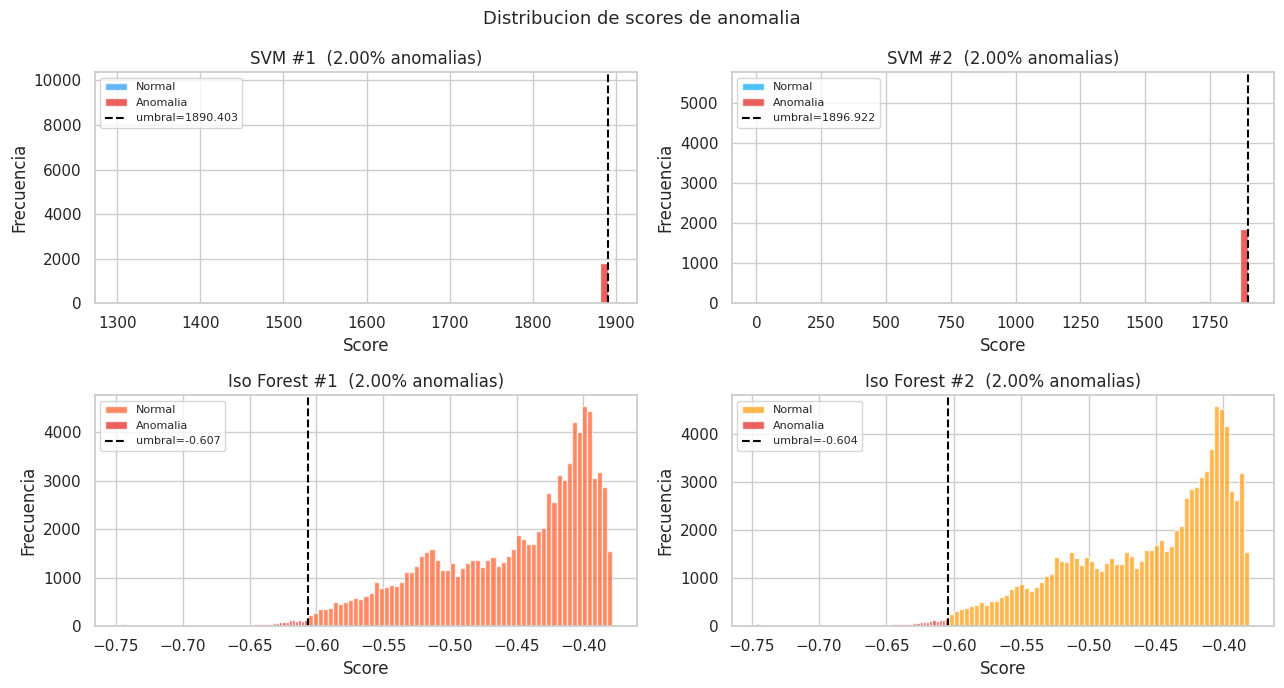

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
fig.suptitle('Distribucion de scores de anomalia', fontsize=13)

configs = [
    (best_svm[0], axes[0,0], 'SVM #1',        '#2196F3'),
    (best_svm[1], axes[0,1], 'SVM #2',        '#03A9F4'),
    (best_iso[0], axes[1,0], 'Iso Forest #1', '#FF5722'),
    (best_iso[1], axes[1,1], 'Iso Forest #2', '#FF9800'),
]

for r, ax, title, color in configs:
    thr = np.percentile(r['scores'], CONTAMINATION * 100)
    ax.hist(r['scores'][r['preds'] ==  1], bins=60, alpha=0.7, color=color,     label='Normal')
    ax.hist(r['scores'][r['preds'] == -1], bins=60, alpha=0.8, color='#E53935', label='Anomalia')
    ax.axvline(thr, color='black', linestyle='--', linewidth=1.5, label=f'umbral={thr:.3f}')
    ax.set_title(f'{title}  ({r["ratio"]*100:.2f}% anomalias)')
    ax.set_xlabel('Score'); ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('distribucion_scores.png', dpi=150, bbox_inches='tight')
plt.show()

### DataFrames con etiquetas  (1 = anomalia, 0 = normal)

In [11]:
df_svm_labels = df_sub.copy()
df_svm_labels['anomalia'] = np.where(best_svm[0]['preds'] == -1, 1, 0)

df_iso_labels = df_sub.copy()
df_iso_labels['anomalia'] = np.where(best_iso[0]['preds'] == -1, 1, 0)

print('SVM  ->', df_svm_labels['anomalia'].value_counts().to_dict())
print('ISO  ->', df_iso_labels['anomalia'].value_counts().to_dict())

SVM  -> {0: 93810, 1: 1914}
ISO  -> {0: 93809, 1: 1915}


### Interseccion

Ambos detectan  : 750  (0.78%)
Solo SVM        : 1,164  (1.22%)
Solo ISO        : 1,165  (1.22%)
Normal (ambos)  : 92,645  (96.78%)


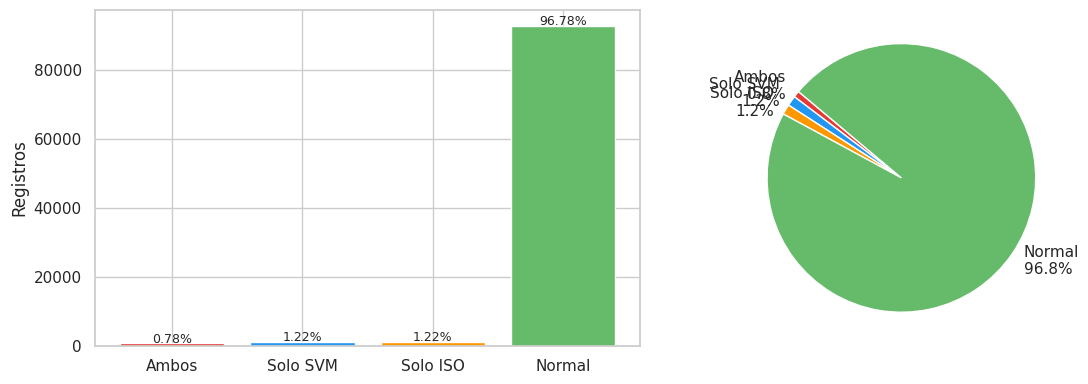

In [12]:
svm_anom = df_svm_labels['anomalia'] == 1
iso_anom = df_iso_labels['anomalia'] == 1

ambos    = svm_anom & iso_anom
solo_svm = svm_anom & ~iso_anom
solo_iso = iso_anom & ~svm_anom
ninguno  = ~svm_anom & ~iso_anom

n = len(df_sub)
print(f'Ambos detectan  : {ambos.sum():,}  ({ambos.mean()*100:.2f}%)')
print(f'Solo SVM        : {solo_svm.sum():,}  ({solo_svm.mean()*100:.2f}%)')
print(f'Solo ISO        : {solo_iso.sum():,}  ({solo_iso.mean()*100:.2f}%)')
print(f'Normal (ambos)  : {ninguno.sum():,}  ({ninguno.mean()*100:.2f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cats   = ['Ambos', 'Solo SVM', 'Solo ISO', 'Normal']
counts = [ambos.sum(), solo_svm.sum(), solo_iso.sum(), ninguno.sum()]
colors = ['#E53935', '#2196F3', '#FF9800', '#66BB6A']

axes[0].bar(cats, counts, color=colors, edgecolor='white')
for i, v in enumerate(counts):
    axes[0].text(i, v + n*0.002, f'{v/n*100:.2f}%', ha='center', fontsize=9)
axes[0].set_ylabel('Registros')

axes[1].pie(counts, labels=[f'{c}\n{v/n*100:.1f}%' for c, v in zip(cats, counts)],
            colors=colors, startangle=140)

plt.tight_layout()
plt.savefig('comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

### Set de evaluacion — interseccion + normales + ruido

In [13]:
NOISE = 0.05  # probar tambien 0.10

df_anom   = df_sub[ambos].copy()
df_normal = df_sub[ninguno].sample(n=len(df_anom), random_state=RANDOM_STATE).copy()

def add_noise(df_in, pct, seed=RANDOM_STATE):
    np.random.seed(seed)
    return pd.DataFrame(
        df_in.values + np.random.normal(0, pct, df_in.shape),
        columns=df_in.columns, index=df_in.index
    )

X_eval = pd.concat([add_noise(df_anom, NOISE), add_noise(df_normal, NOISE)])
y_eval = np.concatenate([np.ones(len(df_anom)), np.zeros(len(df_normal))])
X_eval_sc = scaler.transform(X_eval[col_interes])

print(f'{len(X_eval)} muestras  —  {len(df_anom)} anomalias / {len(df_normal)} normales')

1500 muestras  —  750 anomalias / 750 normales


### F1-Score

In [14]:
for nombre, r in [('SVM', best_svm[0]), ('Isolation Forest', best_iso[0])]:
    y_pred = np.where(r['model'].predict(X_eval_sc) == -1, 1, 0)
    print(f'\n── {nombre} ──')
    print(classification_report(y_eval, y_pred, target_names=['Normal', 'Anomalia'], zero_division=0))


── SVM ──
              precision    recall  f1-score   support

      Normal       0.81      0.44      0.57       750
    Anomalia       0.61      0.90      0.73       750

    accuracy                           0.67      1500
   macro avg       0.71      0.67      0.65      1500
weighted avg       0.71      0.67      0.65      1500


── Isolation Forest ──
              precision    recall  f1-score   support

      Normal       0.85      0.81      0.83       750
    Anomalia       0.82      0.86      0.84       750

    accuracy                           0.83      1500
   macro avg       0.84      0.83      0.83      1500
weighted avg       0.84      0.83      0.83      1500



***Nota:*** Con precisión, recall etc, se refiere a si es consistente consigo mismo. Como no existen etiquetas que digan si un proceso fue bien soldado o mal soldado, lo que usa es comparar si lo que detecto como anomalía o un proceso normal, es consistente con el resto que marco de igual forma.

**SVM:** El algoritmo SVM muestra resultados moderados para Estacion 150, Sch1. Tiene valores de precisión y recall muy similares, lo que indica que no tiene un sesgo muy agresivo. Sin embargo, con un F1 de 0.69 en ambas clases, muestra que el modelo no distingue tan facilmente entre procesos normales y anómalos. Esta apenas encima de adivinar al azar. 

**Isolation Forest :** Por otro lado, este muestra mejores resultados. 0.79 de precision y 0.87 en anomalías indica que es consistente con lo que considera anómalo y puede señaralo con cierta certeza. Los valores normales tambien los maneja decentemente (0.86/0.77). Con un F1 de 0.83, mantiene un desempeño bueno a pesar de tener datos dispersos (según el TSNE).

**Resumen:** SVM parece estar adivinando anomalias para cumplir la discriminación del 2%, mientras que Isolation Forest pareció encontrar una estructura entre los datos 

In [15]:
import joblib

# Exportar el mejor Isolation Forest y su scaler
joblib.dump(best_iso[0]['model'], 'modelo_iso_est140Sch1.pkl')
joblib.dump(scaler,               'scaler_est140Sch1.pkl')
print("Exportado.")

Exportado.
